In [2]:
import sys
if "tf_env" not in sys.executable:
    print("/n环境配置错误!!!/n")
    print(sys.executable)
else:
    print("环境配置正常")

环境配置正常


In [3]:
import numpy  as np
import pandas as pd
import matplotlib.pyplot as plt 
from matplotlib import rcParams # 字体配置,支持中文
rcParams['font.family'] = 'SimHei'
rcParams['axes.unicode_minus'] = False  # 解决负号不显示的问题

import tensorflow as tf

In [4]:
# ===== 线性回归模型的构建 =====

In [5]:
# 1. 构建数据集
def synthetic_data(w, b, num_examples):  #@save
    """生成y=Xw+b+噪声"""
    X = tf.zeros((num_examples, w.shape[0]))
    X += tf.random.normal(shape=X.shape)
    y = tf.matmul(X, tf.reshape(w, (-1, 1))) + b
    y += tf.random.normal(shape=y.shape, stddev=0.01)
    y = tf.reshape(y, (-1, 1))
    return X, y

true_w = tf.constant([2,-3.4]) # 权重
true_b = 4.2    # 偏置
features, labels = synthetic_data(true_w, true_b, 1000) # features中的每一行都包含一个二维数据样本

# 绘图看看效果
# plt.scatter(features[:,0] , labels , color='blue')
# plt.scatter(features[:,1] , labels , color='red' )
# plt.show()

In [6]:
# 2. 读取数据集
'''
从大批量数据中抽取一小部分作为数据集
'''
# 该函数接收批量大小、特征矩阵和标签向量作为输入，生成大小为batch_size的小批量
def data_iter(batch_size, features, labels):
    num_examples = len(features)
    indices = list(range(num_examples))
    # 这些样本是随机读取的，没有特定的顺序
    np.random.shuffle(indices)  # 原random.shuffle(indices)
    for i in range(0, num_examples, batch_size):
        j = tf.constant(indices[i: min(i + batch_size, num_examples)])
        yield tf.gather(features, j), tf.gather(labels, j)


batch_size = 10

for X, y in data_iter(batch_size, features, labels):
    print(X, '\n', y)
    break

tf.Tensor(
[[ 0.12510979 -0.5360051 ]
 [ 0.60815156 -2.2649918 ]
 [ 0.23744011  0.7094275 ]
 [ 0.21149258 -1.4993428 ]
 [ 0.74570364 -0.28579554]
 [ 0.45487654 -0.7099063 ]
 [-0.19030862 -0.49653268]
 [ 0.26941094  0.7629734 ]
 [-0.15659659  0.60020566]
 [-1.4777496   0.6795459 ]], shape=(10, 2), dtype=float32) 
 tf.Tensor(
[[ 6.2739644]
 [13.114537 ]
 [ 2.2783878]
 [ 9.719034 ]
 [ 6.6503935]
 [ 7.5239673]
 [ 5.5165915]
 [ 2.1459305]
 [ 1.8499954]
 [-1.0826367]], shape=(10, 1), dtype=float32)


In [7]:
# 3. 初始化模型参数
# 模型预测需要给定参数,这里进行随机化
w = tf.Variable(tf.random.normal(shape=(2, 1), mean=0, stddev=0.01),
                trainable=True)

b = tf.Variable(tf.zeros(1), trainable=True)


In [8]:
# 4. 定义模型 向量X@w再加偏置b
def linreg(X, w, b):  #@save
    """线性回归模型"""
    return tf.matmul(X, w) + b

In [9]:
# 5. 定义损失函数: 平方损失函数
# 真实值y 预测值y_hat , 需要形状相同
def squared_loss(y_hat, y):  #@save
    """均方损失"""
    return (y_hat - tf.reshape(y, y_hat.shape)) ** 2 / 2

梯度计算和小批量随机梯度下降算法原理:
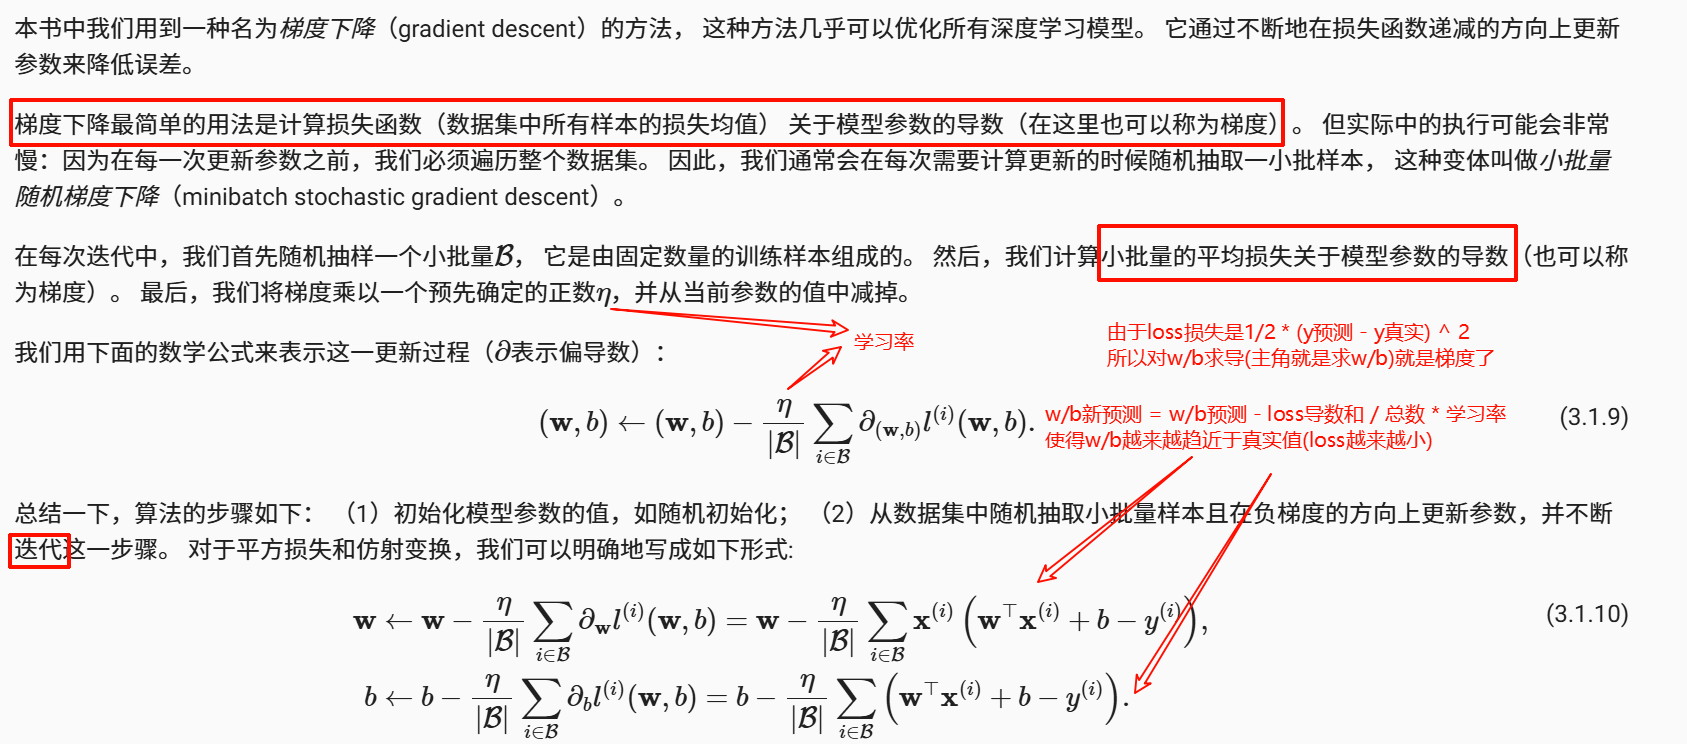

In [10]:
# 6. 定义优化算法: 小批量随机梯度下降
# 使用从数据集中随机抽取的一个小批量，然后根据参数计算损失的梯度
# batch_size: 批量大小 lr: 学习速率
# 新参数=旧参数−学习率×梯度
def sgd(params, grads, lr, batch_size):  #@save
    """小批量随机梯度下降"""
    for param, grad in zip(params, grads):
        param.assign_sub(lr * grad/batch_size) # param = param - 学习速率 * 平均梯度(loss和的导数/小批量数据的数目)(or梯度和的平均)

In [11]:
# 7. 训练
# 目标: 1. 初始化参数 2. 重复以下训练: 计算新梯度 -> 更新参数 w/b = w/b - 学习速率 * 平均梯度
lr = 0.03 # 学习速率
num_epochs = 3 # 小范围数据量
net = linreg   # 模型函数重命名: f(x) = w * x + b
loss= squared_loss # 损失函数重命名(平均均值损失函数)

for epoch in range(num_epochs):
    for X ,y in data_iter(batch_size, features, labels): # 小范围数据
        # 微分计算
        with tf.GradientTape() as g:
            l = loss(net(X,w,b) , y) # # X和y的小批量损失
        dw , db = g.gradient(l,[w,b])
        # 计算l关于[w,b]的梯度
        sgd([w,b] , [dw , db] , lr , batch_size)
    train_l = loss(net(features , w , b) , labels)
    print(f'epoch {epoch + 1}, loss {float(tf.reduce_mean(train_l)):f}')
print(f'w的估计误差: {true_w - tf.reshape(w, true_w.shape)}')
print(f'b的估计误差: {true_b - b}')

epoch 1, loss 0.026636
epoch 2, loss 0.000098
epoch 3, loss 0.000051
w的估计误差: [-0.00031424 -0.0002656 ]
b的估计误差: [0.00054502]
